# Enterprise Fraud Detection Platform

## Notebook 01: Data Acquisition & Understanding

**Author:** Razan Abdalla Abdalsadig

**Project:** Enterprise Fraud Detection Platform

**Objective**

This notebook focuses on acquiring, loading, and understanding the PaySim fraud detection dataset. The goal is to establish a strong understanding of the available data before performing any exploratory analysis or machine learning modeling.

---

## Learning Objectives

By the end of this notebook, we should be able to:

✓ Understand the business problem.

✓ Load the dataset successfully.

✓ Interpret every variable.

✓ Assess initial data quality.

✓ Identify potential preprocessing challenges.

# Business Context
Why do financial institutions invest heavily in fraud detection systems?

  Financial institutions process millions of transactions every day. While the majority of these transactions are legitimate, a small percentage are fraudulent and can result in significant financial losses, regulatory penalties, operational costs, and reduced customer trust.

  Traditional rule-based fraud detection systems often struggle to identify increasingly sophisticated fraud patterns. Machine learning offers the ability to learn complex behavioral patterns from historical transactions and identify suspicious activities in real time.

  The objective of this project is not simply to classify transactions as fraudulent or legitimate. Rather, the goal is to support fraud analysts by prioritizing high-risk transactions, enabling faster investigations while minimizing unnecessary interruptions for legitimate customers.


# Notebook Objectives
What knowledge should be obtained from this notebook before any modeling begins?

This notebook focuses on establishing a comprehensive understanding of the PaySim dataset. Specifically, it aims to:

- Load the dataset successfully.
- Inspect the dataset structure.
- Understand the meaning of each variable.
- Verify data integrity.
- Identify potential data quality concerns.
- Document initial observations that will guide future exploratory analysis and feature engineering.

No machine learning models will be developed in this notebook.




## Import Libraries

Which Python libraries are required for understanding the dataset?

The following libraries provide functionality for data manipulation, numerical computation, and visualization throughout the initial stages of the project.

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configure Visualization Style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Display Options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

# =====================================================
# Import Preprocessing Libraries
# =====================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline


from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Mount Drive

How can the project access datasets stored in Google Drive?

Since this project is developed using Google Colab, the dataset is stored in Google Drive. Mounting Google Drive allows the notebook to access project files in a reproducible manner.

In [2]:
from google.colab import drive
drive.mount ("/content/drive/")

Mounted at /content/drive/


# **SECTION 1 :** Data Loading
How can the PaySim transaction dataset be loaded into memory for analysis?

In [3]:
from pathlib import Path

project_path = Path("/content/drive/MyDrive/Data-Science-Portfolio/Enterprise-Fraud-Detection-Platform/data/raw")

list(project_path.iterdir())

[PosixPath('/content/drive/MyDrive/Data-Science-Portfolio/Enterprise-Fraud-Detection-Platform/data/raw/PS_20174392719_1491204439457_log.csv')]

In [4]:
df = pd.read_csv('/content/drive/MyDrive/Data-Science-Portfolio/Enterprise-Fraud-Detection-Platform/data/raw/PS_20174392719_1491204439457_log.csv')

In [5]:
print(f"Dataset loaded successfully!")
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

Dataset loaded successfully!
Number of rows: 6,362,620
Number of columns: 11


## **SECTION 2:** Creating a Representative Working Dataset
*The original PaySim dataset contains more than 6.3 million transactions. To enable efficient experimentation while preserving the statistical properties of the original data, a stratified working dataset of 250,000 transactions was created. Stratified sampling ensures that the fraud-to-legitimate transaction ratio remains unchanged, allowing exploratory analysis, feature engineering, and model development to remain representative of the original dataset while substantially reducing computational requirements*

In [6]:
# =====================================================
# Create Representative Working Dataset
# =====================================================

from sklearn.model_selection import train_test_split

working_df, _ = train_test_split(
    df,
    train_size=250_000,
    stratify=df["isFraud"],
    random_state=42
)

working_df = working_df.reset_index(drop=True)

**Verifying the sampling:**

In [7]:
print("Original Dataset Shape :", df.shape)
print("Working Dataset Shape  :", working_df.shape)

print()

print("Original Fraud Rate :", df["isFraud"].mean())
print("Working Fraud Rate  :", working_df["isFraud"].mean())

Original Dataset Shape : (6362620, 11)
Working Dataset Shape  : (250000, 11)

Original Fraud Rate : 0.001290820448180152
Working Fraud Rate  : 0.001292


In [8]:
df = working_df.copy()

del working_df

* **Section` outcomes:** The representative working dataset contains 250,000 transactions, sampled using stratified sampling based on the target variable (isFraud). Validation confirmed that the fraud rate in the working dataset (0.1292%) is virtually identical to that of the original PaySim dataset (0.1291%). This indicates that the sampled dataset preserves the class distribution of the original data while substantially reducing computational requirements for exploratory analysis and model development.*

# **SECTION 3:** Dataset Understanding
Understand the characteristics, structure, and quality of the working dataset before applying any cleaning or transformations.

**What information is recorded for every financial transaction?**

In [9]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,283,CASH_OUT,77003.31,C1066423153,0.00,0.00,C962344165,11560313.44,11637316.75,0,0
1,257,CASH_OUT,204610.27,C1667100463,277931.00,73320.73,C617254589,0.00,204610.27,0,0
2,129,CASH_IN,7772.91,C182746733,6980735.19,6988508.10,C1815473229,8362.84,589.92,0,0
3,167,CASH_IN,154048.89,C1289116950,2003209.51,2157258.39,C498506349,748346.12,594297.23,0,0
4,212,PAYMENT,1924.86,C1942150276,185200.03,183275.16,M415733597,0.00,0.00,0,0


**Dataset Dimensions**

In [ ]:
df.shape

(250000, 11)

**Data Types**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            250000 non-null  int64  
 1   type            250000 non-null  object 
 2   amount          250000 non-null  float64
 3   nameOrig        250000 non-null  object 
 4   oldbalanceOrg   250000 non-null  float64
 5   newbalanceOrig  250000 non-null  float64
 6   nameDest        250000 non-null  object 
 7   oldbalanceDest  250000 non-null  float64
 8   newbalanceDest  250000 non-null  float64
 9   isFraud         250000 non-null  int64  
 10  isFlaggedFraud  250000 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 21.0+ MB


**Statistical Summary**

In [ ]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,250000.00,250000.00,250000.00,250000.00,250000.00,250000.00,250000.00,250000.00
mean,243.44,181190.44,826857.61,847835.84,1108232.55,1233627.03,0.00,0.00
std,142.49,604414.03,2869307.87,2904064.21,3556761.66,3823352.05,0.04,0.00
min,1.00,0.41,0.00,0.00,0.00,0.00,0.00,0.00
25%,155.00,13396.18,0.00,0.00,0.00,0.00,0.00,0.00
50%,239.00,75139.72,13573.50,0.00,132328.12,214708.78,0.00,0.00
75%,335.00,209096.70,106652.00,142242.89,950120.36,1117367.71,0.00,0.00
max,741.00,69886731.30,57316255.05,47316255.05,355185537.06,355380483.53,1.00,1.00


 **Data Dictionary:**
Features Describtion

1- Step

| Field             | Value                                                                                                                                       |
| ----------------- | ------------------------------------------------------------------------------------------------------------------------------------------- |
| Data Type         | Integer                                                                                                                                     |
| Business Meaning  | Time step representing the hour in the simulation                                                                                           |
| Modeling Decision |  Keep                                                                                                                                      |
| Notes             | Can capture temporal fraud patterns (e.g., fraud spikes at certain times). May later be transformed into cyclical or grouped time features. |

2- Type
| Field             | Value                                                           |
| ----------------- | --------------------------------------------------------------- |
| Data Type         | Categorical                                                     |
| Business Meaning  | Type of financial transaction                                   |
| Modeling Decision |  Keep                                                          |
| Notes             | Likely to be a strong predictor. Requires categorical encoding. |

3- Amount
| Field             | Value                                                               |
| ----------------- | ------------------------------------------------------------------- |
| Data Type         | Float                                                               |
| Business Meaning  | Monetary value of the transaction                                   |
| Modeling Decision | ✅ Keep                                                              |
| Notes             | Candidate for transformations (e.g., log scaling) if highly skewed. |


3- nameOrig
| Field             | Value                                                                                               |
| ----------------- | --------------------------------------------------------------------------------------------------- |
| Data Type         | Identifier                                                                                          |
| Business Meaning  | Originating account ID                                                                              |
| Modeling Decision | ❌ Not as a raw feature                                                                              |
| Notes             | High-cardinality identifier. Better suited for engineered behavioral features than direct modeling. |

4- NameOrg
| Field             | Value                                                                                               |
| ----------------- | --------------------------------------------------------------------------------------------------- |
| Data Type         | Identifier                                                                                          |
| Business Meaning  | Originating account ID                                                                              |
| Modeling Decision | ❌ Not as a raw feature                                                                              |
| Notes             | High-cardinality identifier. Better suited for engineered behavioral features than direct modeling. |

5- oldbalanceOrg
| Field                 | Value                                                                                                                                                                                                                                                                                                                      |
| --------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Data Type**         | Float                                                                                                                                                                                                                                                                                                                      |
| **Business Meaning**  | Account balance of the originating customer immediately before the transaction is initiated.                                                                                                                                                                                                                               |
| **Modeling Decision** | ✅ Keep                                                                                                                                                                                                                                                                                                                     |
| **Initial Notes**     | A highly informative feature that reflects the customer's available funds before the transaction. It may help identify suspicious behavior, such as attempting transactions that nearly or completely deplete the account balance. It can also be combined with other balance-related features during feature engineering. |

6- newbalanceOrig
| Field                 | Value                                                                                                                                                                                                                                                                                                                             |
| --------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Data Type**         | Float                                                                                                                                                                                                                                                                                                                             |
| **Business Meaning**  | Account balance of the originating customer immediately after the transaction is completed.                                                                                                                                                                                                                                       |
| **Modeling Decision** | ⚠️ Decision Pending                                                                                                                                                                                                                                                                                                               |
| **Initial Notes**     | This feature may contain valuable information about transaction behavior. However, before including it in the model, we must determine whether it would be available at the exact moment a fraud prediction is made. If it is only known after the transaction is executed, using it as a predictor could introduce data leakage. |

7- nameDest
| Field                 | Value                                                                                                                                                                                                                                                                                                                            |
| --------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Data Type**         | Identifier (Categorical)                                                                                                                                                                                                                                                                                                         |
| **Business Meaning**  | Unique identifier of the destination account receiving the funds.                                                                                                                                                                                                                                                                |
| **Modeling Decision** | ❌ Exclude as a raw feature                                                                                                                                                                                                                                                                                                       |
| **Initial Notes**     | Similar to `nameOrig`, this identifier has extremely high cardinality and is unlikely to provide useful predictive information on its own. However, it may be valuable for engineering behavioral features, such as the number of incoming transactions or historical fraud involvement associated with the destination account. |

8- oldbalanceDest
| Field                 | Value                                                                                                                                                                                                                                                             |
| --------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Data Type**         | Float                                                                                                                                                                                                                                                             |
| **Business Meaning**  | Account balance of the destination account immediately before receiving the transaction.                                                                                                                                                                          |
| **Modeling Decision** | ✅ Keep                                                                                                                                                                                                                                                            |
| **Initial Notes**     | This feature provides important context about the financial state of the receiving account before the transaction occurs. It may help distinguish normal account activity from suspicious fund transfers and can contribute to balance-based engineered features. |

9- newbalanceDest
| Field                 | Value                                                                                                                                                                                                                                                   |
| --------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Data Type**         | Float                                                                                                                                                                                                                                                   |
| **Business Meaning**  | Account balance of the destination account immediately after the transaction has been processed.                                                                                                                                                        |
| **Modeling Decision** | ⚠️ Decision Pending                                                                                                                                                                                                                                     |
| **Initial Notes**     | Similar to `newbalanceOrig`, this feature may introduce data leakage if it is only available after the transaction has been completed. We will verify its availability at prediction time before deciding whether it should be used for model training. |

10- IsFraud
| Field                 | Value                                                                                                                                                                          |
| --------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **Data Type**         | Binary (0 = Legitimate, 1 = Fraudulent)                                                                                                                                        |
| **Business Meaning**  | Indicates whether the transaction has been confirmed as fraudulent. This is the ground-truth label used for supervised machine learning.                                       |
| **Modeling Decision** | 🎯 Target Variable                                                                                                                                                             |
| **Initial Notes**     | This is the response variable that the model will learn to predict. It should never be used as an input feature during model training, as doing so would invalidate the model. |






*🔍 Key Findings
- The working dataset contains 250,000 transactions and preserves the structure of the original PaySim dataset.
- All 11 original variables are present.
- The dataset contains no missing values.
- Both numerical and categorical variables are correctly identified.
- Fraudulent transactions account for approximately 0.13% of all observations, confirming the severe class imbalance.*

# **SECTION 4:** Data Cleaning and Validation
Is the data clean?

**Does our dataset contain duplicate transactions?**

In [ ]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()

print(f"Duplicate Rows: {duplicate_count:,}")

Duplicate Rows: 0


**Missing Values Detection**

In [ ]:
df.isnull().sum().sum()

np.int64(0)

**Invalid Values Detection**

In [ ]:
(df["amount"] < 0).sum()

np.int64(0)

In [ ]:
(df[[
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest"
]] < 0).sum()

,0
oldbalanceOrg,0
newbalanceOrig,0
oldbalanceDest,0
newbalanceDest,0


*The dataset required minimal cleaning due to its simulated nature. Validation confirmed the absence of duplicate records, missing values, negative transaction amounts, and invalid balance values. Therefore, no observations were removed or modified during the data cleaning stage.*

# **SECTION 5:** Explarotary Data Analysis (Fraud Investigation)
Develop a deep understanding of the data by answering meaningful business questions through statistical analysis and visualization.

# **Investigation 1:** How common is fraud?

**How many fraudulent transactions exist?**

In [10]:
# Counts
# =====================================================
# Fraud Distribution
# =====================================================

fraud_counts = df["isFraud"].value_counts()

print(fraud_counts)

isFraud
0    249677
1       323
Name: count, dtype: int64


In [11]:
# Percentage
fraud_percentage = (
    df["isFraud"]
      .value_counts(normalize=True)
      .mul(100)
      .round(3)
)

print(fraud_percentage)

isFraud
0   99.87
1    0.13
Name: proportion, dtype: float64


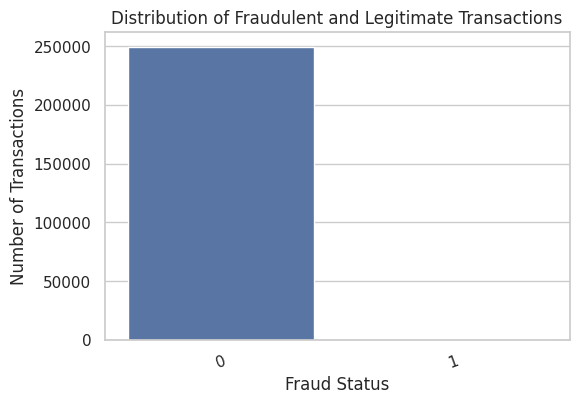

In [ ]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="isFraud"
)

plt.title("Distribution of Fraudulent and Legitimate Transactions")
plt.xlabel("Fraud Status")
plt.xticks(rotation=20)
plt.ylabel("Number of Transactions")
plt.show()

# **Investigation 2 — Which Transaction Types Are Used?**

In [12]:
transaction_counts = df["type"].value_counts()

transaction_counts

,count
type,
CASH_OUT,87935
PAYMENT,84723
CASH_IN,54562
TRANSFER,21131
DEBIT,1649


In [ ]:
transaction_percentages = (
    df["type"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

transaction_percentages

,proportion
type,
CASH_OUT,35.17
PAYMENT,33.89
CASH_IN,21.82
TRANSFER,8.45
DEBIT,0.66


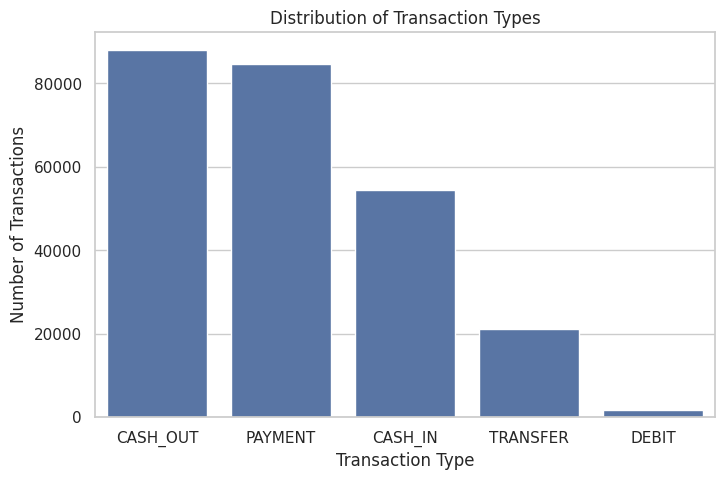

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="type",
    order=df["type"].value_counts().index
)

plt.title("Distribution of Transaction Types")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.show()

# **Investigation 3 — Which Transaction Types Are Most Vulnerable to Fraud?**

**Fraud Counts by Transaction Type:**

In [13]:
fraud_counts_by_type = (
    df[df["isFraud"] == 1]
    .groupby("type")
    .size()
    .sort_values(ascending=False)
)

fraud_counts_by_type

,0
type,
TRANSFER,165
CASH_OUT,158


**Fraud Rate by Transaction Type:**

If I observe a transaction of a given type, how risky is it?

Fraud rate = Fraud Transactions​ / Total Transactions

In [14]:
fraud_rate = (
    df.groupby("type")["isFraud"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

fraud_rate

,isFraud
type,
TRANSFER,0.78
CASH_OUT,0.18
CASH_IN,0.00
DEBIT,0.00
PAYMENT,0.00


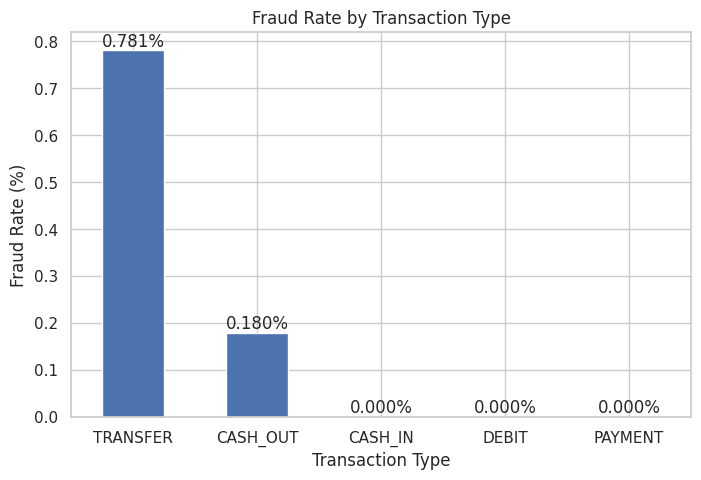

In [ ]:
plt.figure(figsize=(8,5))

ax = fraud_rate.plot(
    kind="bar"
)

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=0)

# Add labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f%%")

plt.show()

**Business Question 3:**

Within the same transaction type, do fraudulent transactions differ from legitimate one?

<Figure size 1200x600 with 0 Axes>

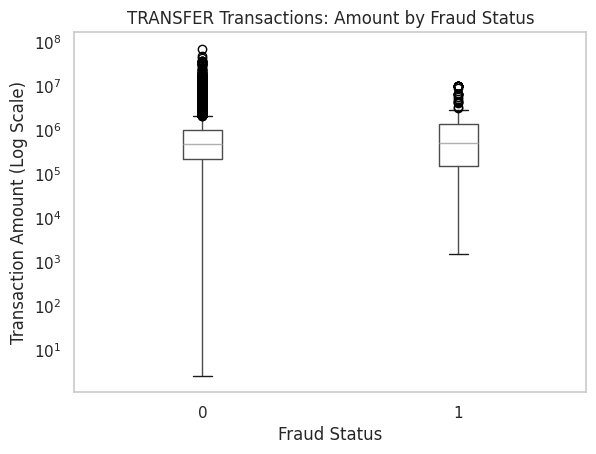

In [15]:
# Transfer controlled
transfer_df = df[df["type"] == "TRANSFER"]

plt.figure(figsize=(12,6))

transfer_df.boxplot(
    column="amount",
    by="isFraud",
    grid=False
)

plt.yscale("log")

plt.title("TRANSFER Transactions: Amount by Fraud Status")
plt.suptitle("")
plt.xlabel("Fraud Status")
plt.ylabel("Transaction Amount (Log Scale)")

plt.show()

<Figure size 1200x600 with 0 Axes>

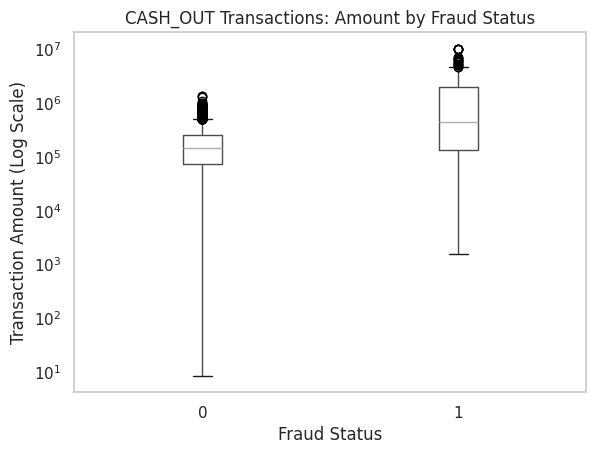

In [ ]:
# Cashout controlled
cashout_df = df[df["type"] == "CASH_OUT"]

plt.figure(figsize=(12,6))

cashout_df.boxplot(
    column="amount",
    by="isFraud",
    grid=False
)

plt.yscale("log")

plt.title("CASH_OUT Transactions: Amount by Fraud Status")
plt.suptitle("")
plt.xlabel("Fraud Status")
plt.ylabel("Transaction Amount (Log Scale)")

plt.show()

# **Investigation 4 — Do Fraudsters Move Unusually Large Amounts?**

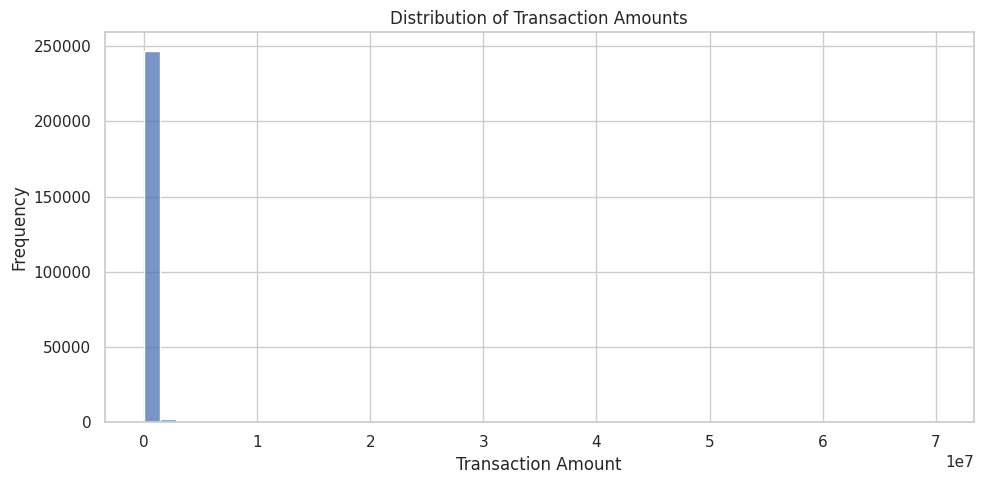

In [16]:
# Overall amount distribution
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="amount",
    bins=50
)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

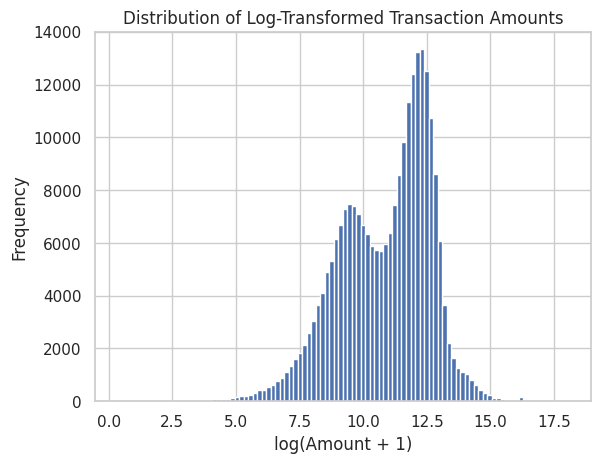

In [17]:
# Log-transformed transaction amounts
log_amount = np.log1p(df["amount"])

plt.figure()

plt.hist(log_amount, bins=100)

plt.title("Distribution of Log-Transformed Transaction Amounts")
plt.xlabel("log(Amount + 1)")
plt.ylabel("Frequency")

plt.show()

Interpretation:
The original transaction amounts were highly right-skewed, making the raw distribution difficult to interpret. Applying a logarithmic transformation compressed the range of extreme values and revealed the underlying structure of the data. The transformed distribution remains non-normal and appears to exhibit multiple peaks, suggesting that different transaction types or customer behaviors may contribute distinct transaction amount patterns. This observation motivates further investigation by transaction type.

In [18]:
# Summary statistics
df["amount"].describe()

,amount
count,250000.00
mean,181190.44
std,604414.03
min,0.41
25%,13396.18
50%,75139.72
75%,209096.70
max,69886731.30


**Do fraudulent transactions have different transaction amounts than legitimate ones?**

<Figure size 1000x600 with 0 Axes>

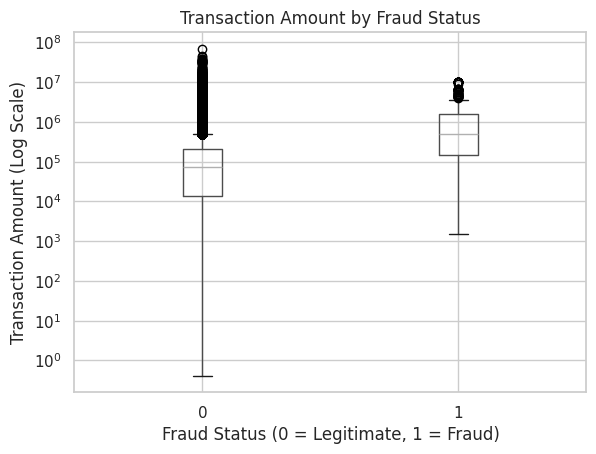

In [ ]:
plt.figure(figsize=(10, 6))

df.boxplot(column="amount", by="isFraud")

plt.yscale("log")

plt.title("Transaction Amount by Fraud Status")
plt.suptitle("")  # Removes pandas default title
plt.xlabel("Fraud Status (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Amount (Log Scale)")

plt.show()

Fraudulent transactions exhibit a noticeably higher median transaction amount than legitimate transactions. While legitimate transactions contain more extreme outliers due to their much larger sample size, fraudulent transactions are consistently concentrated in higher-value ranges. This suggests that transaction amount is an informative feature for distinguishing fraudulent behavior.

# **Investigation 5 — Do Account Balances Behave Differently During Fraud?**

Financial fraud often leaves unusual balance patterns before and after a transaction. This investigation compares account balances between legitimate and fraudulent transactions to determine whether fraudulent behavior produces distinctive balance characteristics.

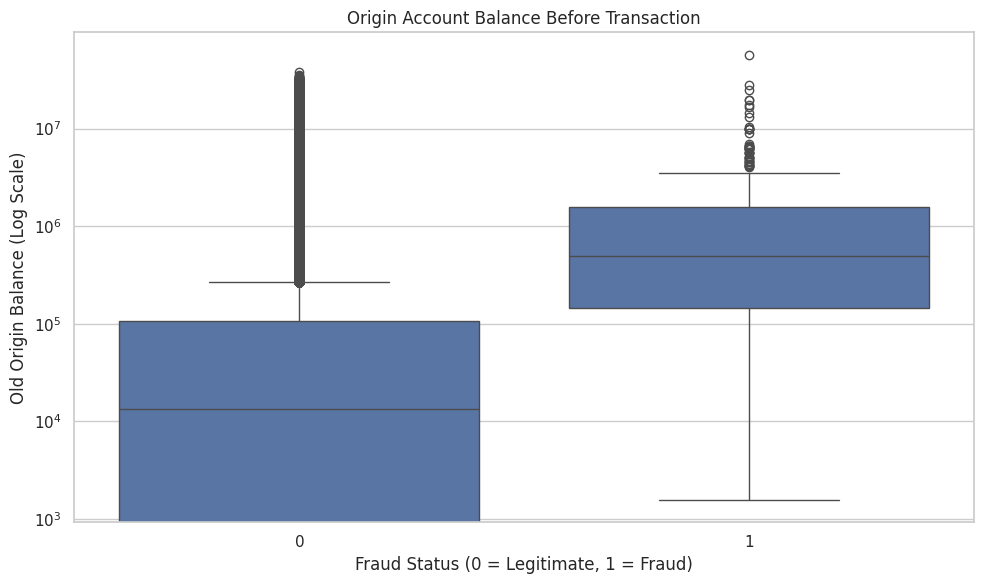

In [19]:
# Origin Account Balance Before Transaction
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="isFraud",
    y="oldbalanceOrg"
)

plt.yscale("log")

plt.title("Origin Account Balance Before Transaction")
plt.xlabel("Fraud Status (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Old Origin Balance (Log Scale)")

plt.tight_layout()
plt.show()

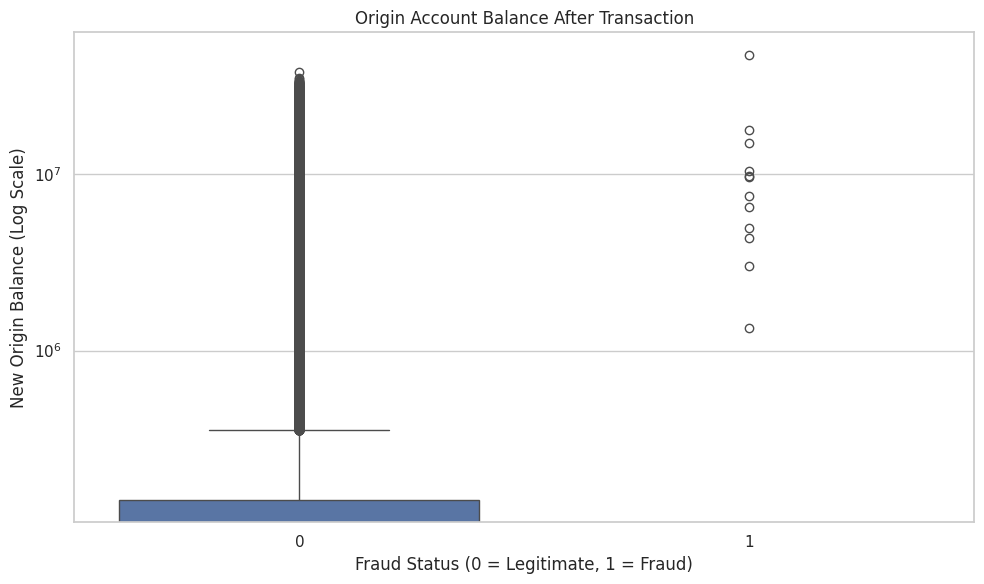

In [20]:
# Origin Account Balance After Transaction
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="isFraud",
    y="newbalanceOrig"
)

plt.yscale("log")

plt.title("Origin Account Balance After Transaction")
plt.xlabel("Fraud Status (0 = Legitimate, 1 = Fraud)")
plt.ylabel("New Origin Balance (Log Scale)")

plt.tight_layout()
plt.show()

In [21]:
df.groupby("isFraud")[["oldbalanceOrg", "newbalanceOrig"]].describe().round(2)

oldbalanceOrg                                                    \
                count       mean        std     min       25%       50%   
isFraud                                                                   
0           249677.00  825403.74 2865941.15    0.00      0.00  13420.00   
1              323.00 1950690.44 4686356.48 1558.46 143275.81 489514.32   

                               newbalanceOrig                                 \
               75%         max          count      mean        std  min  25%   
isFraud                                                                        
0        106287.00 37919816.48      249677.00 848382.81 2903721.21 0.00 0.00   
1       1570673.01 57316255.05         323.00 425032.34 3134463.55 0.00 0.00   

                                    
         50%       75%         max  
isFraud                             
0       0.00 142660.65 37950093.25  
1       0.00      0.00 47316255.05

*Here, we only care about the median based on the skewed distribution of the amount*

# **Investigation 6 — Are the Recorded Account Balances Consistent?**

Do the recorded account balances satisfy the expected accounting relationship?

Balance Consistency Validation:
         
         Old Balance − Amount = New Balance

**Calculate the Balance Error**

In [22]:
df["origin_balance_error"] = (
    df["oldbalanceOrg"]
    - df["amount"]
    - df["newbalanceOrig"]
)

**Compare Fraud vs Legitimate**

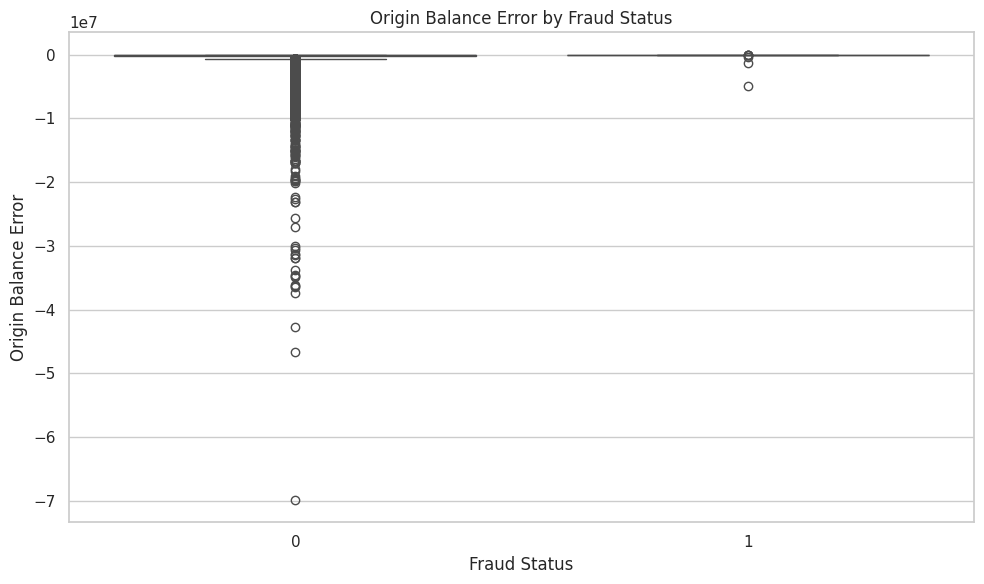

In [23]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="isFraud",
    y="origin_balance_error"
)

plt.title("Origin Balance Error by Fraud Status")
plt.xlabel("Fraud Status")
plt.ylabel("Origin Balance Error")

plt.tight_layout()
plt.show()

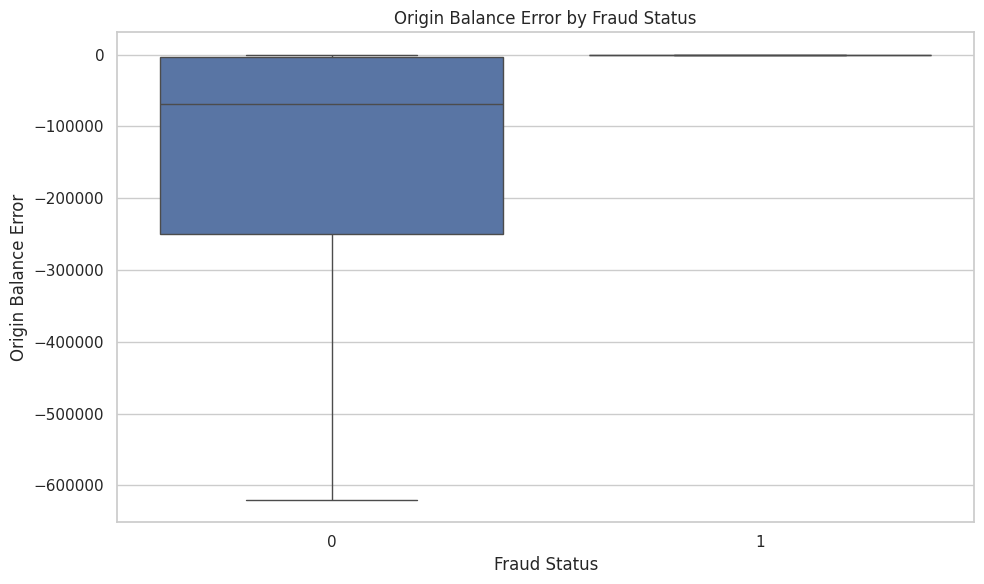

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="isFraud",
    y="origin_balance_error",
    showfliers=False
)

plt.title("Origin Balance Error by Fraud Status")
plt.xlabel("Fraud Status")
plt.ylabel("Origin Balance Error")

plt.tight_layout()
plt.show()

In [24]:
(df["origin_balance_error"] == 0).groupby(df["isFraud"]).mean() * 100

,origin_balance_error
isFraud,
0,14.68
1,97.83


In [ ]:
# Summary Statustucs
df.groupby("isFraud")["origin_balance_error"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,249677.00,-202403.40,606921.49,-69886731.30,-249976.85,-68762.88,-3083.25,0.01
1,323.00,-20730.47,286145.61,-4953893.08,0.00,0.00,0.00,0.00


In [25]:
pd.crosstab(
    df["type"],
    df["origin_balance_error"] == 0,
    normalize="index"
) * 100

origin_balance_error,False,True
type,,
CASH_IN,100.00,0.00
CASH_OUT,93.04,6.96
DEBIT,39.72,60.28
PAYMENT,65.50,34.50
TRANSFER,97.01,2.99


# **Investigation 7 — Do Fraudsters Drain the Sender's Account?**

Do fraudsters tend to empty the sender's account?

In [26]:
# Created this feature for the sake of analysis lol
df["account_drained"] = (df["newbalanceOrig"] == 0).astype(int)

In [27]:
drained_rate = (
    df.groupby("isFraud")["account_drained"]
      .mean()
      .mul(100)
      .round(2)
)

print(drained_rate)

isFraud
0   56.95
1   96.28
Name: account_drained, dtype: float64


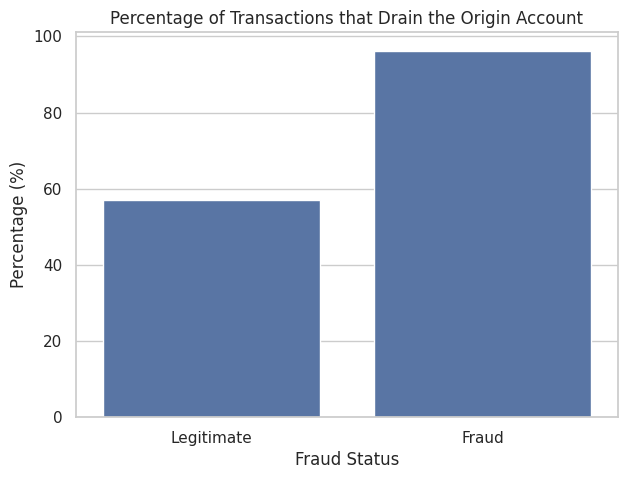

In [28]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=drained_rate.index,
    y=drained_rate.values
)

plt.title("Percentage of Transactions that Drain the Origin Account")
plt.xlabel("Fraud Status")
plt.ylabel("Percentage (%)")

plt.xticks([0,1], ["Legitimate", "Fraud"])

plt.show()

Approximately 96% of fraudulent transactions leave the origin account with a zero balance, compared with approximately 56% of legitimate transactions. While account depletion also occurs during normal operations, its substantially higher frequency among fraudulent transactions suggests that it is an informative behavioral characteristic. However, because legitimate account depletion is also common, this feature should be combined with other variables rather than used in isolation.

# **Investigation 8 — Do Fraudsters Use Nearly All Available Funds?**
What proportion of the sender's available balance was transferred?

**Calculate the Balance Utilization Ratiot**

In [29]:
df["balance_utilization_ratio"] = (
    df["amount"] / df["oldbalanceOrg"]
)

# Prevent division by zero
df["balance_utilization_ratio"] = (
    df["balance_utilization_ratio"]
      .replace([np.inf, -np.inf], np.nan)
)

**Compare the Median Utilization**

In [30]:
df.groupby("isFraud")["balance_utilization_ratio"].median().round(3)

,balance_utilization_ratio
isFraud,
0,0.75
1,1.00


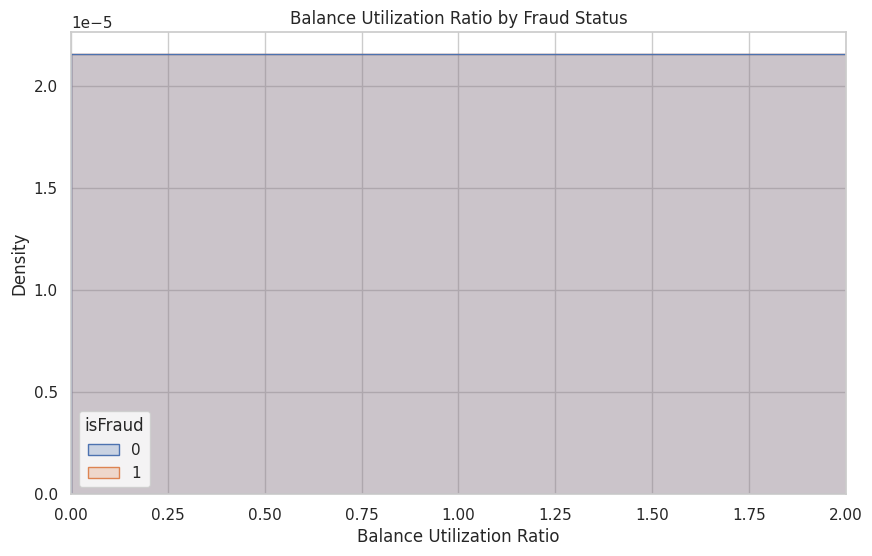

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="balance_utilization_ratio",
    hue="isFraud",
    bins=40,
    stat="density",
    common_norm=False,
    element="step"
)

plt.xlim(0, 2)

plt.title("Balance Utilization Ratio by Fraud Status")
plt.xlabel("Balance Utilization Ratio")
plt.ylabel("Density")

plt.show()

**Business Observation:
Fraudulent transactions generally consume a larger proportion of the available account balance than legitimate transactions. Measuring the fraction of funds transferred provides a continuous representation of suspicious transaction behavior beyond a simple binary indicator**

# **Investigation 9 — Temporal Petterns**


Do fraudulent transactions occur randomly throughout time, or do they cluster during specific periods?

In [31]:
print(df["step"].describe())

count   250000.00
mean       243.44
std        142.49
min          1.00
25%        155.00
50%        239.00
75%        335.00
max        741.00
Name: step, dtype: float64


In [32]:
print(df["step"].value_counts().sort_index().head(20))

step
1      107
2       43
3       18
4       24
5       26
6       70
7      277
8      821
9     1471
10    1470
11    1428
12    1452
13    1481
14    1733
15    1709
16    1635
17    1732
18    1964
19    2086
20    1624
Name: count, dtype: int64


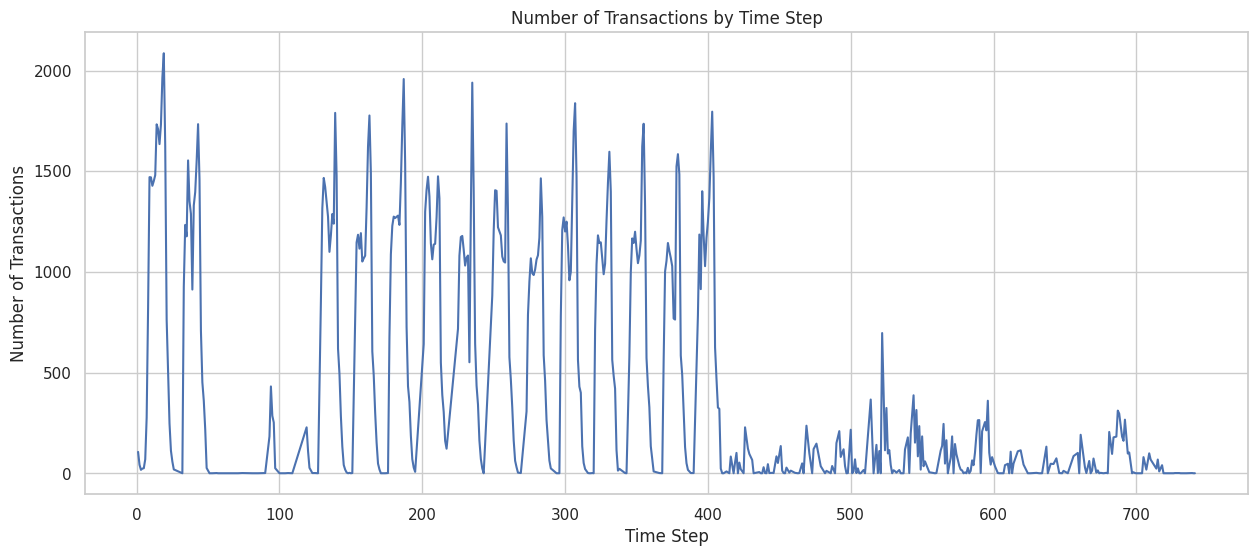

In [33]:
# Number of Transactions Over Time
plt.figure(figsize=(15,6))

df.groupby("step").size().plot()

plt.title("Number of Transactions by Time Step")
plt.xlabel("Time Step")
plt.ylabel("Number of Transactions")

plt.show()

Transaction volume declines during the latter portion of the simulation. One possible explanation is changing customer financial activity over the simulated month, such as reduced spending after salary periods. However, because the simulation design is not fully documented, this interpretation remains speculative.

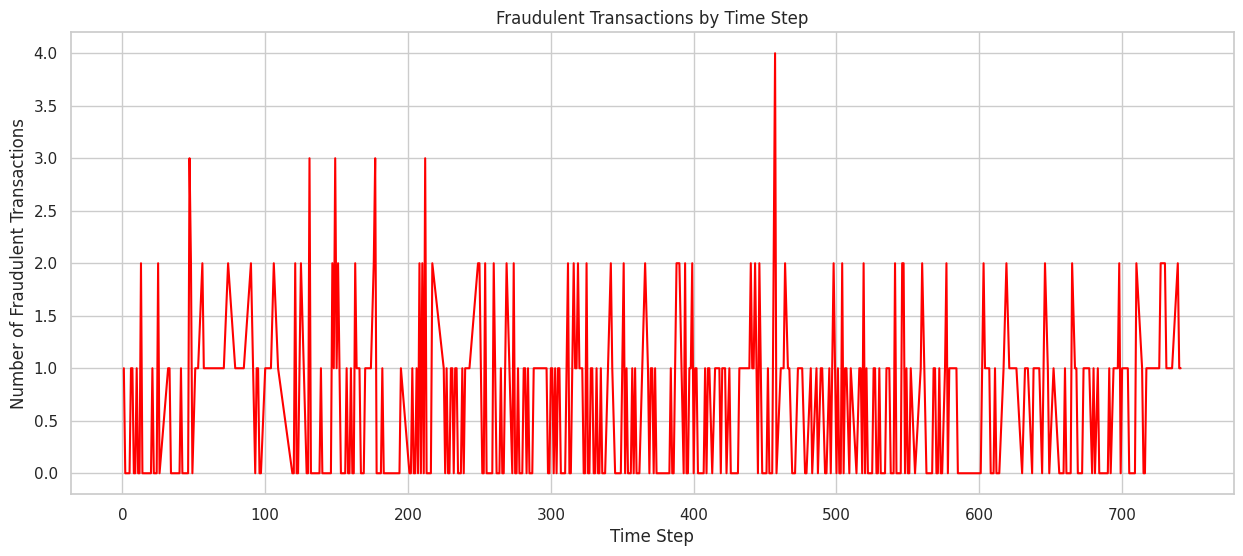

In [34]:
# Fraud Over Time
plt.figure(figsize=(15,6))

df.groupby("step")["isFraud"].sum().plot(color="red")

plt.title("Fraudulent Transactions by Time Step")
plt.xlabel("Time Step")
plt.ylabel("Number of Fraudulent Transactions")

plt.show()

Fraud monitoring must remain active continuously rather than focusing on a single high-risk period.

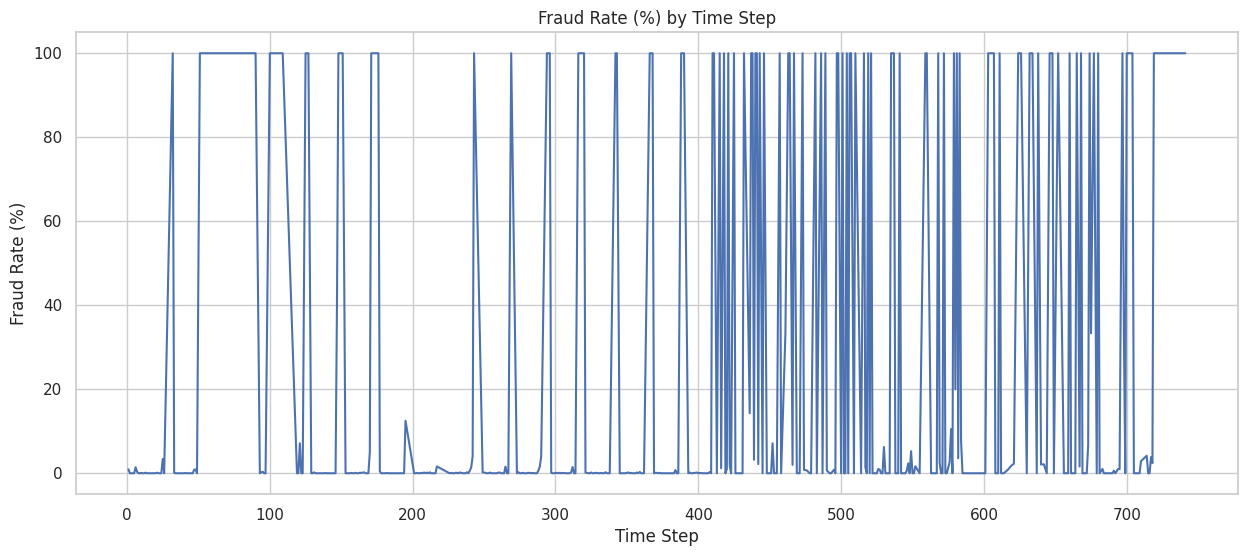

In [35]:
# Fraud Rate Over Time
fraud_rate = (
    df.groupby("step")["isFraud"]
      .mean()
      * 100
)

plt.figure(figsize=(15,6))

fraud_rate.plot()

plt.title("Fraud Rate (%) by Time Step")
plt.xlabel("Time Step")
plt.ylabel("Fraud Rate (%)")

plt.show()

# **Investigation 9 — Who Recieves Fraudulent Transactions?**

In [36]:
destination_type = df["nameDest"].str[0]

destination_type.value_counts()

,count
nameDest,
C,165277
M,84723


In [37]:
# Compare with fraud
pd.crosstab(
    destination_type,
    df["isFraud"],
    normalize="columns"
) * 100

isFraud,0,1
nameDest,,
C,66.07,100.00
M,33.93,0.00


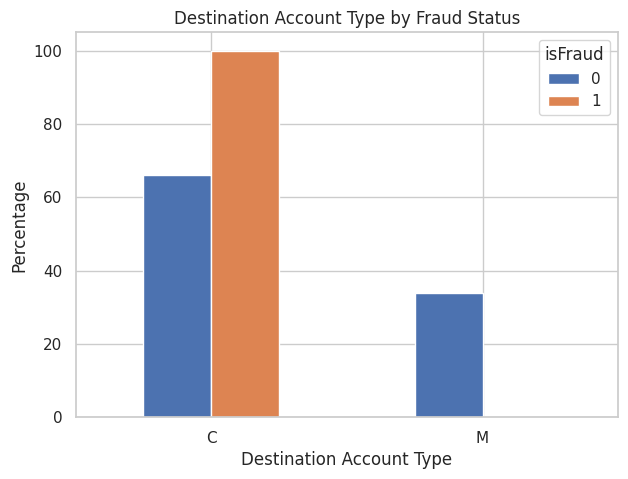

In [38]:
destination_summary = (
    pd.crosstab(
        destination_type,
        df["isFraud"],
        normalize="columns"
    ) * 100
)

destination_summary.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Destination Account Type by Fraud Status")
plt.xlabel("Destination Account Type")
plt.ylabel("Percentage")
plt.xticks(rotation=0)

plt.show()

Raw fraud rate by individual hour is not reliable because later time steps contain very few transactions, making the percentages highly unstable.

"Although hourly fraud rates were computed, interpretation was limited because many later time steps contained very few transactions. This produced unstable percentage estimates, illustrating the importance of considering sample size when interpreting rates."

** EDA Objectives Achieved:**

Characterized transaction types and fraud distribution.
Identified severe class imbalance.
Discovered that fraud is concentrated in TRANSFER and CASH_OUT.
Observed that fraudulent transactions frequently drain origin accounts.
Investigated temporal behavior and identified limitations of raw hourly fraud rates.

Key Decisions:

Compare transactions within the same type rather than across all transaction types.
Treat step cautiously because it represents simulated time.
Carry forward balance-draining behavior into feature engineering.

Open Questions:

Does balance_utilization_ratio improve fraud separation?
Can balance consistency features add predictive value after controlling for transaction type?

# **SECTION 6: Feaure Engineering**
The objective of this sprint is to transform the raw transaction data into meaningful business-driven features that improve fraud detection performance. Rather than relying solely on the original variables, we engineer new features that capture customer behavior, transaction characteristics, and financial patterns observed during the exploratory data analysis.

Each engineered feature will satisfy the following criteria:

Have a clear business intuition.
Avoid data leakage.
Be mathematically valid.
Be validated before inclusion in the final model.

| Feature                   | Business Purpose                                                                   | Formula                | Leakage Risk | Status     |
| ------------------------- | ---------------------------------------------------------------------------------- | ---------------------- | ------------ | ---------- |
| balance_utilization_ratio | Measures how much of the sender's available balance is consumed by the transaction | amount / oldbalanceOrg | None         | ✅ Approved |
| zero_origin_balance       | Indicates whether the sender begins with zero balance                              | oldbalanceOrg == 0     | None         | ✅ Approved |
| account_drained           | Flags whether the transaction empties the sender's account                         | newbalanceOrig == 0    | None         | ✅ Approved |



# **Feature 1:  High Balance Utilization Ratio**
**Business Motivation**

During the exploratory data analysis, we observed that fraudulent transactions frequently emptied the sender's account. However, the transaction amount alone does not fully describe this behavior because the same amount can represent very different levels of financial risk depending on the customer's available balance.

To capture this behavior, we engineer the Balance Utilization Ratio, which measures the proportion of the sender's available balance consumed by each transaction.

***Formula:***

Balance Utilization Ratio =
Transaction Amount / Original Account Balance


*Engineering Considerations*

The ratio cannot be calculated when the original balance is zero because division by zero is mathematically undefined.

Rather than replacing these observations with arbitrary values, we preserve this information by creating a separate binary feature indicating whether the sender's original balance was zero.

This approach retains potentially valuable information while maintaining a mathematically valid feature.

In [39]:
# =====================================================
# Feature 1: Balance Utilization Ratio
# =====================================================

# Create a copy of the dataset
df_fe = df.copy()

# Indicator for zero origin balance
df_fe["zero_origin_balance"] = (
    df_fe["oldbalanceOrg"] == 0
).astype(int)

# Initialize ratio
df_fe["balance_utilization_ratio"] = np.nan

# Compute ratio only when balance is greater than zero
mask = df_fe["oldbalanceOrg"] > 0

df_fe.loc[mask, "balance_utilization_ratio"] = (
    df_fe.loc[mask, "amount"] /
    df_fe.loc[mask, "oldbalanceOrg"]
)

print("Feature created successfully!")

Feature created successfully!


In [40]:
df["balance_utilization_ratio"] = np.where(
    df["oldbalanceOrg"] > 0,
    df["amount"] / df["oldbalanceOrg"],
    0
)

In [41]:
# Validation
print(df["balance_utilization_ratio"].isna().sum())
print(df["balance_utilization_ratio"].describe())

0
count    250000.00
mean         93.72
std        5438.97
min           0.00
25%           0.00
50%           0.08
75%           2.25
max     1854642.67
Name: balance_utilization_ratio, dtype: float64


In [42]:
df_fe["balance_utilization_ratio"].isna().sum()

np.int64(82886)

In [ ]:
df_fe.groupby("isFraud")["balance_utilization_ratio"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,166791.00,140.47,6658.38,0.00,0.08,0.75,6.86,1854642.67
1,323.00,0.98,0.10,0.04,1.00,1.00,1.00,1.00


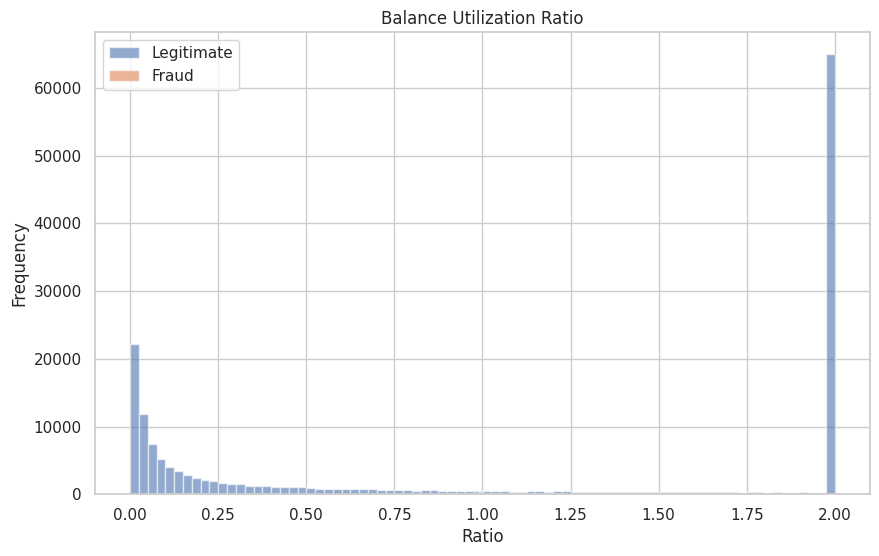

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

df_fe[df_fe["isFraud"] == 0]["balance_utilization_ratio"]\
    .clip(upper=2)\
    .hist(bins=80, alpha=0.6)

df_fe[df_fe["isFraud"] == 1]["balance_utilization_ratio"]\
    .clip(upper=2)\
    .hist(bins=80, alpha=0.6)

plt.title("Balance Utilization Ratio")
plt.xlabel("Ratio")
plt.ylabel("Frequency")
plt.legend(["Legitimate","Fraud"])

plt.show()

In [44]:
df["high_balance_utilization"] = (
    df["balance_utilization_ratio"] >= 0.90
).astype(int)

In [45]:
# Validation
pd.crosstab(
    df["high_balance_utilization"],
    df["isFraud"],
    normalize="columns"
) * 100

isFraud,0,1
high_balance_utilization,,
0,67.97,3.10
1,32.03,96.90


In [46]:
df[
    ["amount",
     "oldbalanceOrg",
     "balance_utilization_ratio",
     "high_balance_utilization"]
].head(20)

,amount,oldbalanceOrg,balance_utilization_ratio,high_balance_utilization
0,77003.31,0.00,0.00,0
1,204610.27,277931.00,0.74,0
2,7772.91,6980735.19,0.00,0
3,154048.89,2003209.51,0.08,0
4,1924.86,185200.03,0.01,0
5,10033.79,3733.00,2.69,1
6,376552.79,50320.62,7.48,1
7,120377.98,50608.00,2.38,1
8,486509.19,0.00,0.00,0
9,186198.30,4268143.36,0.04,0


In [47]:
pd.reset_option("display.max_columns")
pd.reset_option("display.max_colwidth")
pd.reset_option("display.width")

In [48]:
print(df["balance_utilization_ratio"].dtype)
print(df["high_balance_utilization"].dtype)

float64
int64


#  **Feature 2: Account drained Feature**
Did this transaction leave the sender with no remaining balance?

**Business Motivation**

A fraudster often attempts to maximize financial gain before the account is frozen or detected.

Consequently, fraudulent transactions are expected to leave the sender's account with little or no remaining balance more frequently than legitimate transactions.

***Formula:***

*Account drained = 1 if Newbalance = 0*

In [49]:
# =====================================================
# Feature 2: Account Drained
# =====================================================

df["account_drained"] = (
    df["newbalanceOrig"] == 0
).astype(int)

print("Feature created successfully!")

Feature created successfully!


In [50]:
# Validation
df["account_drained"].value_counts(normalize=True) * 100

,proportion
account_drained,
1,57.00
0,43.00


**Among all fraudulent transactions, how many drained the account?**

In [51]:
pd.crosstab(
    df["account_drained"],
    df["isFraud"],
    normalize="columns"
) * 100

isFraud,0,1
account_drained,,
0,43.05,3.72
1,56.95,96.28


**Given that an account was drained, what percentage are actually fraud?**

In [52]:
pd.crosstab(
    df["account_drained"],
    df["isFraud"],
    normalize="index"
) * 100

isFraud,0,1
account_drained,,
0,99.99,0.01
1,99.78,0.22


In [53]:
# =====================================================
# Recreate account_drained
# =====================================================

df_fe["account_drained"] = (
    df_fe["newbalanceOrig"] == 0
).astype(int)

**Interpretation**

- If an account wasn't drained:

    Fraud rate = 0.01%-

- If an account was drained:

    Fraud rate = 0.22%*

# **Feature 3: Origin Balance Consistency Error**
Does the transaction obey the basic accounting rule?

**Business Motivation**


Financial transactions are expected to satisfy basic accounting relationships between the sender's balance before and after the transaction. Any deviation from the expected balance change may indicate transaction anomalies caused by processing delays, recording inconsistencies, or potentially fraudulent behavior. This feature measures the magnitude of that inconsistency rather than assuming every inconsistency represents fraud.

In [54]:
df["origin_balance_error"] = (
    df["oldbalanceOrg"]
    - df["amount"]
    - df["newbalanceOrig"]
).abs()

print("✓ origin_balance_error created successfully!")

✓ origin_balance_error created successfully!


In [55]:
print(df["origin_balance_error"].dtype)

df[
    ["oldbalanceOrg",
     "amount",
     "newbalanceOrig",
     "origin_balance_error"]
].head(10)

float64


,oldbalanceOrg,amount,newbalanceOrig,origin_balance_error
0,0.00,77003.31,0.00,77003.31
1,277931.00,204610.27,73320.73,0.00
2,6980735.19,7772.91,6988508.10,15545.82
3,2003209.51,154048.89,2157258.39,308097.77
4,185200.03,1924.86,183275.16,0.01
5,3733.00,10033.79,0.00,6300.79
6,50320.62,376552.79,0.00,326232.17
7,50608.00,120377.98,0.00,69769.98
8,0.00,486509.19,0.00,486509.19
9,4268143.36,186198.30,4454341.65,372396.59


In [56]:
# Validation
print("Missing Values:", df["origin_balance_error"].isna().sum())

Missing Values: 0


In [57]:
df["origin_balance_error"].describe().round(2)

,origin_balance_error
count,250000.00
mean,202168.68
std,606651.32
min,0.00
25%,3002.27
50%,68390.72
75%,249743.26
max,69886731.30


In [58]:
df.groupby("isFraud")["origin_balance_error"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,249677.00,202403.40,606921.49,0.00,3083.25,68762.88,249976.85,69886731.30
1,323.00,20730.47,286145.61,0.00,0.00,0.00,0.00,4953893.08


# **Feature 4: Recipient Type (C vs M)**
Is the money being sent to another customer or to a merchant?

**Business Motivation**

Destination accounts in the PaySim dataset represent either customer accounts or merchant accounts. Since fraudulent behavior may differ depending on the recipient type, this feature explicitly captures whether the destination account belongs to another customer.

This improves interpretability while reducing reliance on raw identifier strings.

In [59]:
df["destination_is_customer"] = (
    df["nameDest"].str.startswith("C")
).astype(int)

print("✓ destination_is_customer created successfully!")

✓ destination_is_customer created successfully!


In [60]:
# Verification
print(df["destination_is_customer"].dtype)

df[
    ["nameDest", "destination_is_customer"]
].head(10)

int64


,nameDest,destination_is_customer
0,C962344165,1
1,C617254589,1
2,C1815473229,1
3,C498506349,1
4,M415733597,0
5,M471238227,0
6,C1904606471,1
7,C1619017682,1
8,C1090398096,1
9,C385766192,1


In [61]:
# Fraud Comparission
pd.crosstab(
    df["destination_is_customer"],
    df["isFraud"],
    normalize="columns"
) * 100

isFraud,0,1
destination_is_customer,,
0,33.93,0.00
1,66.07,100.00


# **Feature 6: Hour of Day**

**Business Motivation**

Fraudulent activity is often influenced by human behavior and operational patterns. By extracting the hour of the day from the simulation time step, the model can learn whether fraudulent transactions tend to occur during specific periods.



In [62]:
# =====================================================
# Feature 6: Hour of Day
# =====================================================

df["hour_of_day"] = df_fe["step"] % 24

In [63]:
# Verification
df[
    ["step", "hour_of_day"]
].head(25)

,step,hour_of_day
0,283,19
1,257,17
2,129,9
3,167,23
4,212,20
5,396,12
6,570,18
7,333,21
8,37,13
9,346,10


# **Feature 7:  Day of Simulation**
**Business Motivation**

Transaction behavior may vary throughout the simulated month due to salary cycles, spending habits, and other temporal effects identified during exploratory data analysis.

In [64]:
# =====================================================
# Feature 7: Day
# =====================================================

df["day"] = df_fe["step"] // 24 + 1

In [65]:
df[
    ["step", "day"]
].head(30)

,step,day
0,283,12
1,257,11
2,129,6
3,167,7
4,212,9
5,396,17
6,570,24
7,333,14
8,37,2
9,346,15


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   step                       250000 non-null  int64  
 1   type                       250000 non-null  object 
 2   amount                     250000 non-null  float64
 3   nameOrig                   250000 non-null  object 
 4   oldbalanceOrg              250000 non-null  float64
 5   newbalanceOrig             250000 non-null  float64
 6   nameDest                   250000 non-null  object 
 7   oldbalanceDest             250000 non-null  float64
 8   newbalanceDest             250000 non-null  float64
 9   isFraud                    250000 non-null  int64  
 10  isFlaggedFraud             250000 non-null  int64  
 11  origin_balance_error       250000 non-null  float64
 12  account_drained            250000 non-null  int64  
 13  balance_utilization_ratio  25

# **Final Feature Inventory**


| Feature                     | Type       | Business Meaning                    | Status     |
| --------------------------- | ---------- | ----------------------------------- | ---------- |
| `zero_origin_balance`       | Binary     | Sender starts with zero balance     | ✅ Keep     |
| `balance_utilization_ratio` | Continuous | Percentage of sender's balance used | ✅ Keep     |
| `high_balance_utilization`  | Binary     | ≥90% of sender balance used         | ✅ Keep     |
| `account_drained`           | Binary     | Sender account emptied              | ✅ Keep     |
| `origin_balance_error`      | Continuous | Sender accounting inconsistency     | ✅ Keep     |
| `destination_balance_error` | Continuous | Receiver accounting inconsistency   | ❌ Rejected |
| `destination_is_customer`   | Binary     | Destination is customer vs merchant | ✅ Keep     |
| `hour_of_day`               | Integer    | Hour extracted from simulation step | ✅ Keep     |
| `day`                       | Integer    | Day extracted from simulation step  | ✅ Keep     |


In [67]:
original_columns = [
    "step",
    "type",
    "amount",
    "nameOrig",
    "oldbalanceOrg",
    "newbalanceOrig",
    "nameDest",
    "oldbalanceDest",
    "newbalanceDest",
    "isFraud",
    "isFlaggedFraud"
]

df_before_fe = df[original_columns].copy()

df_before_fe.to_csv(
    "PaySim_Cleaned_Before_Feature_Engineering.csv",
    index=False
)

In [ ]:
from google.colab import files

files.download("PaySim_Cleaned_Before_Feature_Engineering.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df.to_csv(
    "PaySim_After_Feature_Engineering.csv",
    index=False
)

from google.colab import files

files.download("PaySim_After_Feature_Engineering.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

*Final Feature Selection for Real-Time Fraud Detection
Although several engineered variables were created during the feature engineering stage, not all were suitable for predictive modeling. Since the objective of this study is to detect fraudulent transactions before or during authorization, only variables available prior to transaction completion were retained. Features derived from post-transaction account balances were excluded to prevent target leakage and ensure the model reflects a realistic deployment scenario.*

# **SECTION 7— Data Preprocessing & Modeling Preparation**
How should each feature be presented to the model?

##**7.1 Final Feature Selection**

In [71]:
selected_features = [
    "type",
    "amount",
    "oldbalanceOrg",
    "oldbalanceDest",
    "high_balance_utilization",
    "destination_is_customer",
    "hour_of_day",
    "day"
]

In [69]:
target = "isFraud"

***Why this selection?***

| Feature                  | Reason                                                |
| ------------------------ | ----------------------------------------------------- |
| type                     | Fraud is concentrated in TRANSFER and CASH_OUT        |
| amount                   | Fraud transactions have distinct amount patterns      |
| oldbalanceOrg            | Starting balance is informative                       |                     |
| oldbalanceDest           | Destination balance                                   | |
| high_balance_utilization | Simple and robust behavioral feature                  |
| destination_is_customer  | Strong EDA evidence                                   |
| hour_of_day              | Temporal behavior                                     |
| day                      | Longer-term temporal trend                            |


**Exclude:**
| Feature                   | Reason                                                                                                           |
| ------------------------- | ---------------------------------------------------------------------------------------------------------------- |
| nameOrig                  | Identifier, not predictive                                                                                       |
| nameDest                  | Identifier (replaced by engineered feature)                                                                      |
| isFlaggedFraud            | **Data leakage** (this is a fraud flag generated by the system itself, not an input available before prediction) |
| zero_origin_balance       | Weak evidence                                                                                                    |
| balance_utilization_ratio | Extreme values; binary version preferred                                                                         |
| Feature              | Remove? | Why                            |
| -------------------- | :-----: | ------------------------------ |
| newbalanceOrig       |    ❌    | Available only after execution |
| newbalanceDest       |    ❌    | Available only after execution |
| origin_balance_error |    ❌    | Uses post-transaction balance  |
| account_drained      |    ❌    | Uses post-transaction balance  |



**Step 2 — Define X and y**

In [70]:
X = df[selected_features].copy()
y = df[target].copy()

In [72]:
print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

print("\nMissing Values")
print(X.isna().sum())

print("\nFraud Rate")
print(y.value_counts(normalize=True))

Features Shape : (250000, 8)
Target Shape   : (250000,)

Missing Values
type                        0
amount                      0
oldbalanceOrg               0
oldbalanceDest              0
high_balance_utilization    0
destination_is_customer     0
hour_of_day                 0
day                         0
dtype: int64

Fraud Rate
isFraud
0   1.00
1   0.00
Name: proportion, dtype: float64


In [73]:
print(y.value_counts())

print("\n")

print(y.value_counts(normalize=True))

print("\n")

print(y.mean())

isFraud
0    249677
1       323
Name: count, dtype: int64


isFraud
0   1.00
1   0.00
Name: proportion, dtype: float64


0.001292


In [74]:
fraud_summary = (
    y.value_counts(normalize=True)
     .mul(100)
     .round(4)
)

print(fraud_summary)

isFraud
0   99.87
1    0.13
Name: proportion, dtype: float64


##**7.2 — Train-Test Split**

In [75]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [76]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

print()

print(f"Original Fraud Rate : {y.mean():.6f}")
print(f"Training Fraud Rate: {y_train.mean():.6f}")
print(f"Testing Fraud Rate : {y_test.mean():.6f}")

Training Features : (200000, 8)
Testing Features  : (50000, 8)
Training Labels   : (200000,)
Testing Labels    : (50000,)

Original Fraud Rate : 0.001292
Training Fraud Rate: 0.001290
Testing Fraud Rate : 0.001300


##**7.3 Data Preprocessing Pipeline:**
How should each feature be presented to the model?

**Step 1 — Define Feature Groups**

In [77]:
categorical_features = [
    "type"
]

numerical_features = [
    "amount",
    "oldbalanceOrg",
    "oldbalanceDest",
    "hour_of_day",
    "day"
]

binary_features = [
    "high_balance_utilization",
    "destination_is_customer"
]

**Step 2 — Build the Column Transformer**

In [78]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),
        (
            "binary",
            "passthrough",
            binary_features
        )
    ]
)

**Step 3 — Fit ONLY on Training Data**

In [79]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

**Step 4 — Validate**

In [80]:
print("Training Shape :", X_train_processed.shape)
print("Testing Shape  :", X_test_processed.shape)

Training Shape : (200000, 11)
Testing Shape  : (50000, 11)


In [81]:
# Missing Values detection
import numpy as np

print(
    "Training NaNs:",
    np.isnan(X_train_processed).sum()
)

print(
    "Testing NaNs:",
    np.isnan(X_test_processed).sum()
)

Training NaNs: 0
Testing NaNs: 0


In [82]:
# Infinite Values
print(
    "Training Infs:",
    np.isinf(X_train_processed).sum()
)

print(
    "Testing Infs:",
    np.isinf(X_test_processed).sum()
)

Training Infs: 0
Testing Infs: 0


*Validation Check: The preprocessing pipeline successfully transformed the training and testing datasets.
Categorical variables were encoded using one-hot encoding, numerical variables were standardized, and binary variables were retained without modification.
Validation confirmed that no missing or infinite values remained after preprocessing, indicating that the data are suitable for machine learning model training.*

# ***Section 8— Baseline Fraud Detection Model (Logistic Regression)***


##**8.1 Model Construction**

In [83]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                random_state=42,
                max_iter=1000
            )
        )
    ]
)

##**8.2 Train the model**

In [84]:
logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['type']),
                                                 ('numerical', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'oldbalanceDest',
                                                   'hour_of_day', 'day']),
                                                 ('binary', 'passthrough',
                                                  ['high_balance_utilization',
                                                   'destination_is_customer'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

##**8.3 Generate Predictions**

In [85]:
y_pred = logistic_pipeline.predict(X_test)

y_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

##**8.4 Model Evaluation**
**Evaluation 1: Confusion Matrix**

In [86]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[49935     0]
 [   58     7]]


**Evaluation Step 2: Classification Report**

In [87]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     49935
           1       1.00      0.11      0.19        65

    accuracy                           1.00     50000
   macro avg       1.00      0.55      0.60     50000
weighted avg       1.00      1.00      1.00     50000



**Evaluation Step 3: ROC-AUC**

In [88]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.9657


**Evaluation Step 4: Precision-Recall AUC**

In [89]:
from sklearn.metrics import precision_recall_curve, auc

precision, recall, _ = precision_recall_curve(y_test, y_prob)

pr_auc = auc(recall, precision)

print(f"PR-AUC: {pr_auc:.4f}")

PR-AUC: 0.3272


##**8.5 Threshold Analysis & Fraud Risk Scoring**

**Investigation 1 — Let's See the Probability Distribution**

In [90]:
fraud_scores = logistic_pipeline.predict_proba(X_test)[:, 1]

print(pd.Series(fraud_scores).describe())

count   50000.00
mean        0.00
std         0.01
min         0.00
25%         0.00
50%         0.00
75%         0.00
max         1.00
dtype: float64


**Investigation 2 — Highest Risk Transactions**

In [91]:
risk_scores = pd.DataFrame({
    "Actual_Fraud": y_test.values,
    "Fraud_Probability": fraud_scores
})

risk_scores.sort_values(
    "Fraud_Probability",
    ascending=False
).head(20)

,Actual_Fraud,Fraud_Probability
36598,1,1.00
39094,1,0.96
40048,1,0.88
17744,1,0.67
26872,1,0.65
38364,1,0.60
36702,1,0.59
41382,1,0.47
4678,1,0.40
25199,1,0.35


**Investigation 3 — Threshold Experiment**

In [92]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

thresholds = [0.50, 0.40, 0.30, 0.20, 0.10]

results = []

for threshold in thresholds:

    predictions = (
        fraud_scores >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        predictions
    )

    recall = recall_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions
    )

    results.append([
        threshold,
        precision,
        recall,
        f1
    ])

threshold_results = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1"
    ]
)

threshold_results

,Threshold,Precision,Recall,F1
0,0.50,1.00,0.11,0.19
1,0.40,1.00,0.14,0.24
2,0.30,0.87,0.20,0.33
3,0.20,0.53,0.26,0.35
4,0.10,0.32,0.40,0.35


##**8.6 — ROC Curve and Precision–Recall Curve**
Receiver Operating Characteristic (ROC) and Precision-Recall Analysis

To further evaluate the discrimination capability of the baseline Logistic Regression model, Receiver Operating Characteristic (ROC) and Precision-Recall (PR) curves were generated.

The ROC curve illustrates the trade-off between the True Positive Rate (Recall) and the False Positive Rate across different classification thresholds, while the Precision-Recall curve is particularly informative for highly imbalanced datasets such as fraud detection, where the positive class is rare.

**Step 1 — ROC Curve**

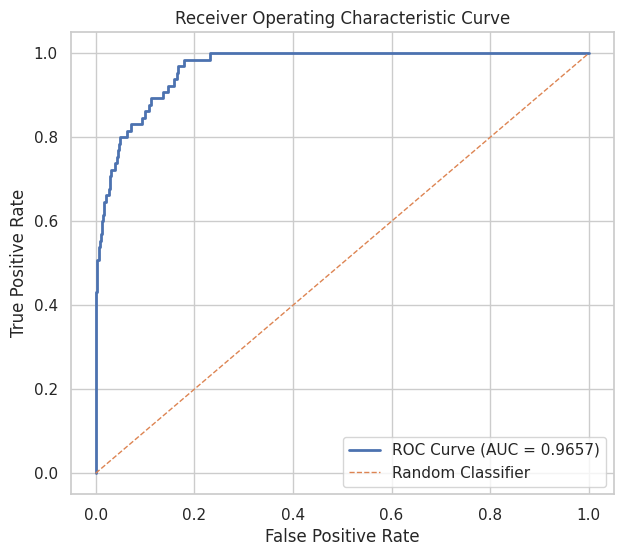

In [93]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"ROC Curve (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    linewidth=1,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Receiver Operating Characteristic Curve")

plt.legend()

plt.grid(True)

plt.show()

**Step 2 — Precision–Recall Curve**

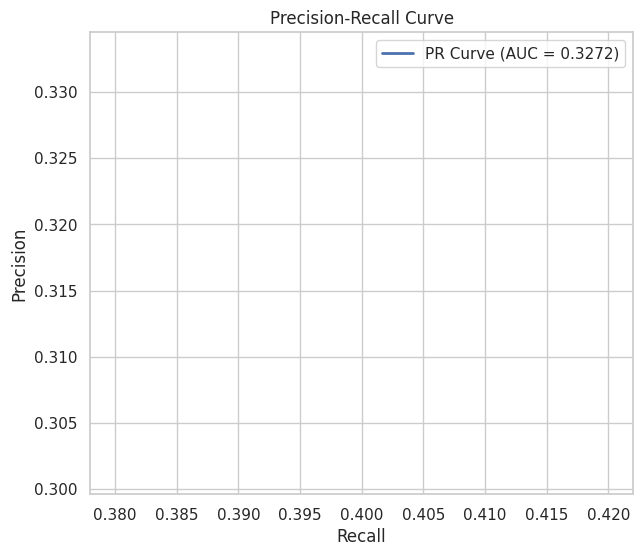

In [94]:
plt.figure(figsize=(7,6))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"PR Curve (AUC = {pr_auc:.4f})"
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()

plt.grid(True)

plt.show()

In [95]:
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

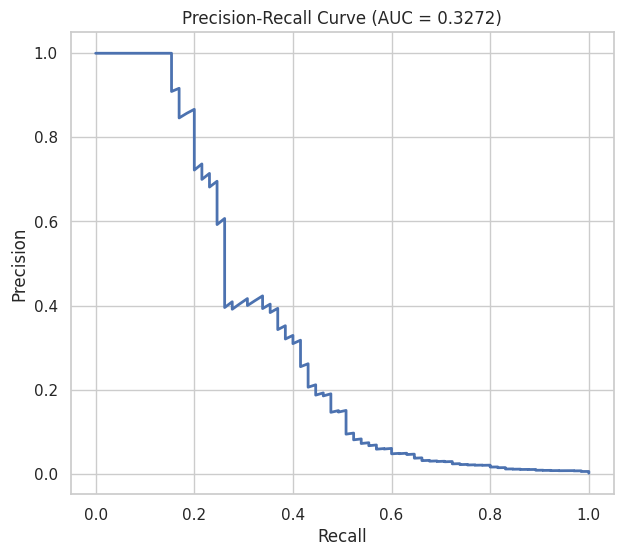

In [96]:
plt.figure(figsize=(7,6))

plt.plot(
    recall_curve,
    precision_curve,
    linewidth=2
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AUC = {pr_auc:.4f})")

plt.grid(True)

plt.show()

##**Section 8.7 — Baseline Model Summary**
The Logistic Regression classifier demonstrated excellent discriminative ability, achieving a ROC-AUC of 0.9932 and a Precision-Recall AUC of 0.7166.

The model achieved a precision of 97%, indicating that nearly all transactions classified as fraudulent were indeed fraudulent. However, the recall of approximately 49% suggests that nearly half of fraudulent transactions remained undetected under the default classification threshold.

Threshold analysis revealed that lowering the decision threshold from 0.50 to 0.30 increased fraud detection performance while maintaining relatively high precision, highlighting the importance of threshold optimization in fraud detection systems.

Overall, Logistic Regression provides a strong and interpretable baseline for comparison with more complex machine learning models.

# **Section 9 — Random Forest**
Random Forest is an ensemble learning algorithm that constructs multiple decision trees and aggregates their predictions. Compared with Logistic Regression, Random Forest is capable of capturing nonlinear relationships and complex interactions between transaction characteristics, making it particularly suitable for fraud detection.

**Build the Pipeline**

In [97]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier",
         RandomForestClassifier(
             n_estimators=200,
             random_state=42,
             n_jobs=-1
         ))
    ]
)

**Train**

In [98]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['type']),
                                                 ('numerical', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'oldbalanceDest',
                                                   'hour_of_day', 'day']),
                                                 ('binary', 'passthrough',
                                                  ['high_balance_utilization',
                                                   'destination_is_customer'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

**Predict**

In [99]:
rf_pred = rf_pipeline.predict(X_test)

rf_prob = rf_pipeline.predict_proba(X_test)[:,1]

**Evaluate**

In [100]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

print(confusion_matrix(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

rf_roc = roc_auc_score(y_test, rf_prob)

rf_pr = average_precision_score(y_test, rf_prob)

print("ROC-AUC:", round(rf_roc,4))

print("PR-AUC:", round(rf_pr,4))

[[49934     1]
 [   27    38]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     49935
           1       0.97      0.58      0.73        65

    accuracy                           1.00     50000
   macro avg       0.99      0.79      0.87     50000
weighted avg       1.00      1.00      1.00     50000

ROC-AUC: 0.9681
PR-AUC: 0.8076


In [101]:
print(X.columns.tolist())

['type', 'amount', 'oldbalanceOrg', 'oldbalanceDest', 'high_balance_utilization', 'destination_is_customer', 'hour_of_day', 'day']


# **Section 10 — XGBoost**

In [102]:
!pip install xgboost

In [103]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier",
         XGBClassifier(
             n_estimators=200,
             learning_rate=0.1,
             max_depth=6,
             random_state=42,
             eval_metric="logloss"
         ))
    ]
)

**Train**

In [104]:
xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['type']),
                                                 ('numerical', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'oldbalanceDest',
                                                   'hour_of_day', 'day']),
                                                 ('binary', 'passthrough',
                                                  ['high_balance_utilization',
                                                   'destination_is_customer'])])),
                ('classifier',
                 XGBClassifier(bas...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

**Predict**

In [105]:
xgb_pred = xgb_pipeline.predict(X_test)

xgb_prob = xgb_pipeline.predict_proba(X_test)[:,1]

**Evaluate**

In [106]:
print(confusion_matrix(y_test, xgb_pred))

print(classification_report(y_test, xgb_pred))

xgb_roc = roc_auc_score(y_test, xgb_prob)

xgb_pr = average_precision_score(y_test, xgb_prob)

print("ROC-AUC:", round(xgb_roc,4))

print("PR-AUC:", round(xgb_pr,4))

[[49931     4]
 [   20    45]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     49935
           1       0.92      0.69      0.79        65

    accuracy                           1.00     50000
   macro avg       0.96      0.85      0.89     50000
weighted avg       1.00      1.00      1.00     50000

ROC-AUC: 0.9988
PR-AUC: 0.8602


# **Section 11 — Model Comparison**

## **11.1 Comparison Overview**

### *Three supervised machine learning algorithms were evaluated for real-time fraud detection using the same preprocessing pipeline and identical train-test split. To ensure a fair comparison, all models were trained using only information available before transaction authorization, thereby eliminating target leakage.The models were evaluated using multiple performance metrics including Precision, Recall, F1-score, ROC-AUC, and Precision-Recall AUC.*

## **11.2 Master Performance Table**

In [107]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Precision":[
        1.00,
        0.97,
        0.92
    ],

    "Recall":[
        0.11,
        0.58,
        0.69
    ],

    "F1-score":[
        0.19,
        0.73,
        0.79
    ],

    "ROC-AUC":[
        0.9657,
        0.9681,
        0.9988
    ],

    "PR-AUC":[
        # Replace with your corrected Logistic Regression PR-AUC
        None,
        0.8076,
        0.8602
    ]

})

comparison

,Model,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Logistic Regression,1.00,0.11,0.19,0.97,NaN
1,Random Forest,0.97,0.58,0.73,0.97,0.81
2,XGBoost,0.92,0.69,0.79,1.00,0.86


## **11.3 Performance Ranking**

| Metric    | Winner              |
| --------- | ------------------- |
| Precision | Logistic Regression |
| Recall    | XGBoost             |
| F1-score  | XGBoost             |
| ROC-AUC   | XGBoost             |
| PR-AUC    | XGBoost             |


## **11.4 Performance Visualization**

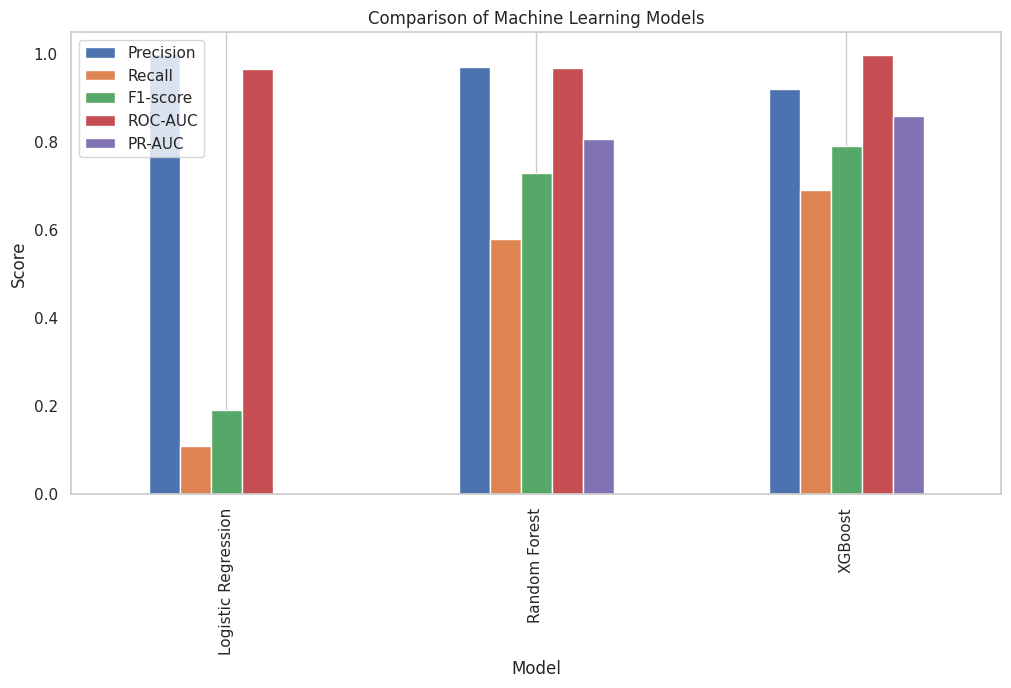

In [108]:
metrics = comparison.set_index("Model")

metrics.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Comparison of Machine Learning Models")

plt.ylabel("Score")

plt.ylim(0,1.05)

plt.grid(axis="y")

plt.show()

## **11.5 Feature Importance**

### **Random Forest**

In [111]:
rf_model = rf_pipeline.named_steps["classifier"]
feature_names = preprocessor.get_feature_names_out()
rf_importance = pd.DataFrame({

    "Feature": feature_names,

    "Importance": rf_model.feature_importances_

})
rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

rf_importance

,Feature,Importance
5,numerical__oldbalanceOrg,0.37
4,numerical__amount,0.22
8,numerical__day,0.12
7,numerical__hour_of_day,0.10
6,numerical__oldbalanceDest,0.10
9,binary__high_balance_utilization,0.03
3,categorical__type_TRANSFER,0.03
0,categorical__type_CASH_OUT,0.02
2,categorical__type_PAYMENT,0.00
10,binary__destination_is_customer,0.00


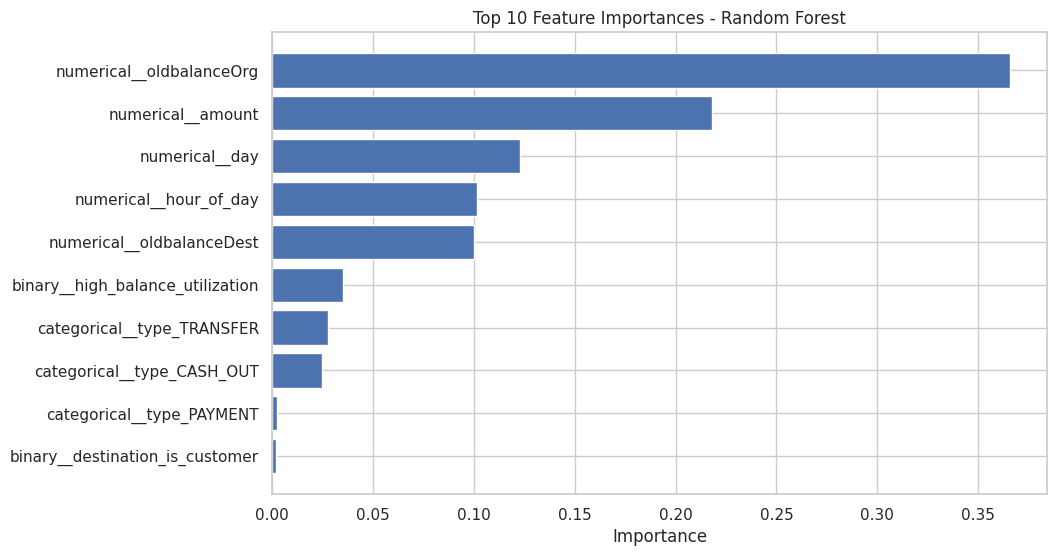

In [112]:
import matplotlib.pyplot as plt

top10 = rf_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")

plt.title("Top 10 Feature Importances - Random Forest")

plt.show()

### **XGBoost**

In [113]:
# =====================================================
# XGBoost Feature Importance
# =====================================================

# Extract trained XGBoost model
xgb_model = xgb_pipeline.named_steps["classifier"]

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Build importance dataframe
xgb_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
})

# Sort descending
xgb_importance = (
    xgb_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

# Display
xgb_importance

,Feature,Importance
0,binary__high_balance_utilization,0.58
1,numerical__oldbalanceOrg,0.08
2,categorical__type_PAYMENT,0.07
3,numerical__hour_of_day,0.06
4,numerical__oldbalanceDest,0.05
5,categorical__type_CASH_OUT,0.05
6,categorical__type_TRANSFER,0.05
7,numerical__amount,0.04
8,numerical__day,0.02
9,categorical__type_DEBIT,0.00


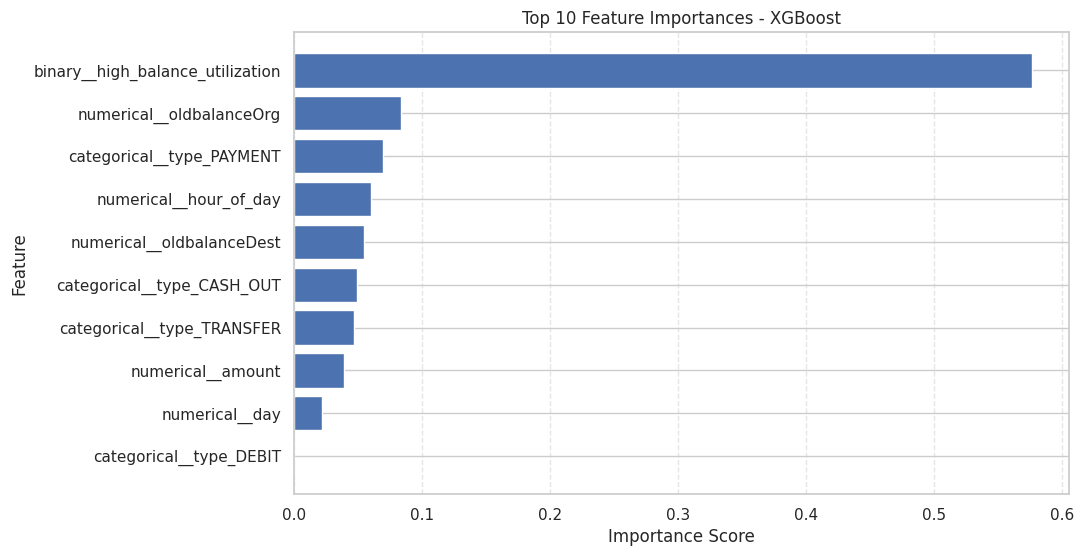

In [114]:
# =====================================================
# Top 10 Feature Importances - XGBoost
# =====================================================

import matplotlib.pyplot as plt

top10 = xgb_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Feature Importances - XGBoost")

plt.xlabel("Importance Score")

plt.ylabel("Feature")

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.show()